In [1]:
from packaging.version import Version
import torch

assert Version(torch.__version__) >= Version("2.6.0")

In [2]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'cpu'

In [3]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def download_and_extract_ridership_data():
    tarball_path = Path("datasets/ridership.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/ridership.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets", filter="data")

download_and_extract_ridership_data()

In [4]:
import pandas as pd
from pathlib import Path

path = Path("datasets/ridership/CTA_-_Ridership_-_Daily_Boarding_Totals.csv")
df = pd.read_csv(path, parse_dates=["service_date"])
df.columns = ["date", "day_type", "bus", "rail", "total"]  # shorter names
df = df.sort_values("date").set_index("date")
df = df.drop("total", axis=1)  # no need for total, it's just bus + rail
df = df.drop_duplicates()  # remove duplicated months (2011-10 and 2014-07)

In [10]:
df

,day_type,bus,rail
date,,,
2001-01-01,U,297192,126455
2001-01-02,W,780827,501952
2001-01-03,W,824923,536432
2001-01-04,W,870021,550011
2001-01-05,W,890426,557917
...,...,...,...
2021-11-26,W,257700,189694
2021-11-27,A,237839,187065
2021-11-28,U,184817,147830


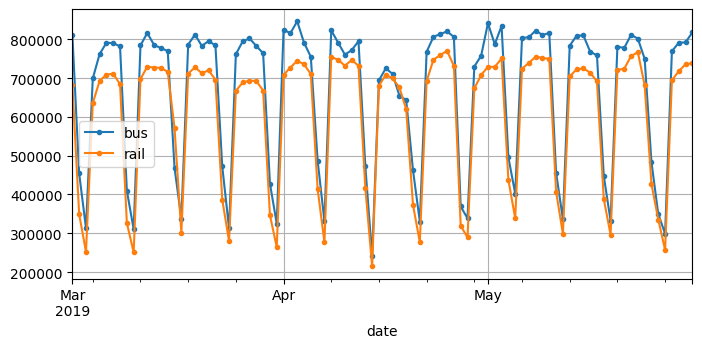

In [5]:
import matplotlib.pyplot as plt

df["2019-03":"2019-05"].plot(grid=True, marker=".", figsize=(8, 3.5))
plt.show()

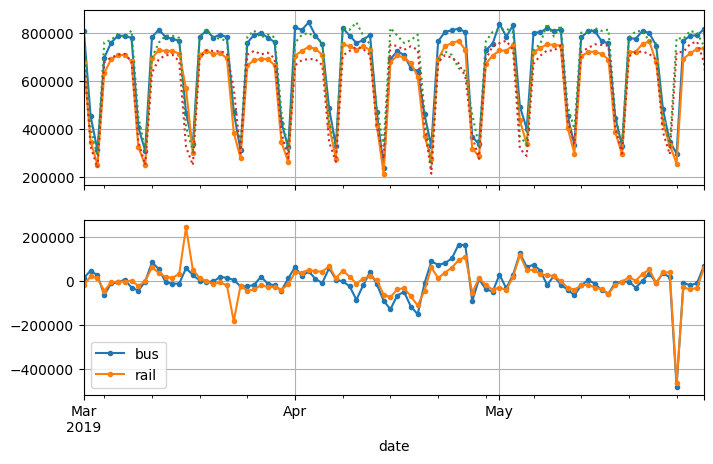

In [6]:
diff_7 = df[["bus", "rail"]].diff(7)["2019-03":"2019-05"]

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(8, 5))
df.plot(ax=axs[0], legend=False, marker=".")  # original time series
df.shift(7).plot(ax=axs[0], grid=True, legend=False, linestyle=":")  # lagged
diff_7.plot(ax=axs[1], grid=True, marker=".")  # 7-day difference time series
axs[0].set_ylim([170_000, 900_000])  # extra code – beautifies the plot

plt.show()

In [7]:
list(df.loc["2019-05-25":"2019-05-27"]["day_type"])

['A', 'U', 'U']

In [8]:
diff_7.abs().mean()

bus     43915.608696
rail    42143.271739
dtype: float64

In [15]:
(diff_7 / df[["bus", "rail"]]["2019-03":"2019-05"]).abs().mean()

bus     0.082938
rail    0.089948
dtype: float64

<Axes: xlabel='date'>

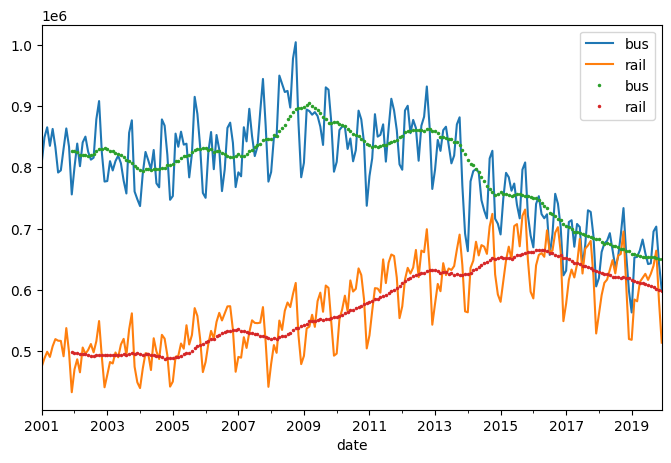

In [69]:
df_monthly = df.select_dtypes(include='number').resample('ME').mean()
df_rolling_12 = df_monthly['2001':'2019'].rolling(window=12).mean()


fig, axs = plt.subplots(figsize=(8, 5))
df_monthly['2001':'2019'].plot(ax=axs)
df_rolling_12.plot(ax=axs, marker='.', markersize=3, linestyle='')

In [70]:
df

,day_type,bus,rail
date,,,
2001-01-01,U,297192,126455
2001-01-02,W,780827,501952
2001-01-03,W,824923,536432
2001-01-04,W,870021,550011
2001-01-05,W,890426,557917
...,...,...,...
2021-11-26,W,257700,189694
2021-11-27,A,237839,187065
2021-11-28,U,184817,147830


In [113]:
s = torch.tensor(np.arange(7).reshape(7,1), dtype=torch.float32)

X = s[1:4] 
y = s[5]

X,y

(tensor([[1.],
         [2.],
         [3.]]),
 tensor([5.]))

In [129]:
s

tensor([[0.],
        [1.],
        [2.],
        [3.],
        [4.],
        [5.],
        [6.]])

In [133]:
# torch.utils.data.Dataset

class TimeSeriesDataset(torch.utils.data.Dataset):
	def __init__(self, series, window_size):
		self.series = series
		self.window_size = window_size
	
	def __len__(self):
		return len(self.series) - self.window_size

	def __getitem__(self, idx):
		if idx >= len(self):
			raise IndexError('asljalsj')
		end = idx+self.window_size
		X = self.series[idx:end]
		y = self.series[end]
		return X, y

t = TimeSeriesDataset(series=s, window_size=3)
for X,y in t:
	print(X,y)

tensor([[0.],
        [1.],
        [2.]]) tensor([3.])
tensor([[1.],
        [2.],
        [3.]]) tensor([4.])
tensor([[2.],
        [3.],
        [4.]]) tensor([5.])
tensor([[3.],
        [4.],
        [5.]]) tensor([6.])


In [147]:
bus_train = torch.Tensor(df[['bus']]["2016-01":"2018-12"].values / 1e6)
bus_test = torch.Tensor(df[['bus']]["2019-01":"2019-05"].values / 1e6)
bus_valid = torch.Tensor(df[['bus']]["2019-06":].values / 1e6)

In [165]:
from torch.utils.data import DataLoader
window_size = 90

train_set = TimeSeriesDataset(bus_train, window_size)
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)

valid_set = TimeSeriesDataset(bus_valid, window_size)
valid_loader = DataLoader(valid_set, batch_size=32)

test_set = TimeSeriesDataset(bus_test, window_size)
test_loader = DataLoader(test_set, batch_size=32)

In [161]:
X_batch,y_batch = next(iter(train_loader))
X_batch.shape, y_batch.shape

(torch.Size([32, 90, 1]), torch.Size([32, 1]))

In [167]:
import torchmetrics

def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
    return metric.compute()

def train(model, optimizer, loss_fn, metric, train_loader, valid_loader,
          n_epochs, patience=10, factor=0.1):
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=patience, factor=factor)
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.0
        metric.reset()
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        history["train_losses"].append(total_loss / len(train_loader))
        history["train_metrics"].append(metric.compute().item())
        val_metric = evaluate_tm(model, valid_loader, metric).item()
        history["valid_metrics"].append(val_metric)
        scheduler.step(val_metric)
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

In [169]:
import torch.nn as nn

model = nn.Sequential(
	nn.Flatten(), 
	nn.Linear(window_size, 1)
).to(device)

loss_fn = nn.HuberLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.003, momentum=0.9)
metric = torchmetrics.MeanAbsoluteError().to(device)

history = train(model, optimizer, loss_fn, metric, train_loader,
                valid_loader, n_epochs=50)

Epoch 1/50, train loss: 0.0287, train metric: 0.2032, valid metric: 0.1116
Epoch 2/50, train loss: 0.0095, train metric: 0.1103, valid metric: 0.0872
Epoch 3/50, train loss: 0.0066, train metric: 0.0822, valid metric: 0.0859
Epoch 4/50, train loss: 0.0060, train metric: 0.0744, valid metric: 0.0899
Epoch 5/50, train loss: 0.0059, train metric: 0.0723, valid metric: 0.0803
Epoch 6/50, train loss: 0.0055, train metric: 0.0704, valid metric: 0.0807
Epoch 7/50, train loss: 0.0054, train metric: 0.0687, valid metric: 0.0822
Epoch 8/50, train loss: 0.0052, train metric: 0.0685, valid metric: 0.0778
Epoch 9/50, train loss: 0.0052, train metric: 0.0678, valid metric: 0.0692
Epoch 10/50, train loss: 0.0053, train metric: 0.0697, valid metric: 0.0726
Epoch 11/50, train loss: 0.0051, train metric: 0.0654, valid metric: 0.0773
Epoch 12/50, train loss: 0.0049, train metric: 0.0654, valid metric: 0.0707
Epoch 13/50, train loss: 0.0048, train metric: 0.0635, valid metric: 0.0687
Epoch 14/50, train lo